In [1]:
!pip install chess cairosvg

In [2]:
import os
import sys
import json
import subprocess
import gc
import torch
import pandas as pd
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split


In [3]:
CONFIG = {
    "colab": True,
    "branch": "main",
    "repo_name": "BigDataAndTextMiningProject",
    "repo_owner": "Aivon99",
    "repo_dir": "/content/BigDataAndTextMiningProject",
}


In [4]:
if CONFIG["colab"]:
    repo_dir = Path(CONFIG["repo_dir"])
    if repo_dir.exists():
        subprocess.run(["rm", "-rf", str(repo_dir)], check=True)

    auth_url = "https://"
    repo_url = f"{auth_url}github.com/{CONFIG['repo_owner']}/{CONFIG['repo_name']}.git"

    result = subprocess.run(
        ["git", "clone", "--single-branch", "--branch", CONFIG["branch"], repo_url, str(repo_dir)],
        capture_output=True, text=True
    )
    assert result.returncode == 0, f"Git clone failed: {result.stderr}"

    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))
else:
    repo_dir = Path(".").resolve()
    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))

REPO_ROOT = Path(".").resolve()
print("Setup Complete. REPO_ROOT:", REPO_ROOT)

Setup Complete. REPO_ROOT: /content/BigDataAndTextMiningProject


In [5]:

repo_root = Path("/content/BigDataAndTextMiningProject")
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "src" / "data"))

from src.data.generation import (
    build_sample,
    generate_dataset,
)

from src.data.utilities import (
    load_lichess_csv,
    upload_dataset_to_hub,
    authenticate_hf,
)

Loading dataset

In [6]:
import shutil
from pathlib import Path

csv_path = Path("lichess_db_puzzle.csv")
zst_path = Path("lichess_db_puzzle.csv.zst")

if not csv_path.exists():
  # 1. Ensure zstd system tool is installed in Colab
  if shutil.which("zstd") is None and shutil.which("unzstd") is None:
    print("Installing zstd decompression tool...")
    !apt-get update -qq && apt-get install -y zstd -qq

  # 2. Download compressed dataset if not present
  if not zst_path.exists():
    print("Downloading Lichess puzzles database (~250 MB compressed)...")
    !wget -q --show-progress https://database.lichess.org/lichess_db_puzzle.csv.zst

  # 3. Decompress to CSV and remove the archive
  print("Decompressing archive (~1.5 GB CSV)...")
  !unzstd -f --rm lichess_db_puzzle.csv.zst -o lichess_db_puzzle.csv

  # 4. Clean up any leftover duplicate downloads
  !rm -f lichess_db_puzzle.csv.zst.*

  print("Decompression complete!")
else:
  print(f"'{csv_path}' already exists.")

lichess_db_puzzle.c 100%[===================>] 290.28M  11.4MB/s    in 27s     
Decompressing archive (~1.5 GB CSV)...
lichess_db_puzzle.csv.zst: 1129374135 bytes 
Decompression complete!


In [7]:
# 1. Load and balance samples (2000 White to move, 2000 Black to move -> 4000 total)
import pandas as pd

#TO modify, just to test
MAX_SAMPLES = 100
N_WHITE_BLACK = 20

df_raw = load_lichess_csv(csv_path=csv_path, max_samples=MAX_SAMPLES)

# Extract the active turn from FEN for balancing ('w' or 'b')
df_raw["turn"] = df_raw["FEN"].apply(
    lambda f: f.split(" ")[1] if len(f.split(" ")) > 1 else "w"
)

# Sample exactly 2000 White and 2000 Black records
df_white = df_raw[df_raw["turn"] == "w"].sample(n=N_WHITE_BLACK, random_state=42)
df_black = df_raw[df_raw["turn"] == "b"].sample(n=N_WHITE_BLACK, random_state=42)

df_balanced = (
    pd.concat([df_white, df_black])
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f"Balanced dataset loaded: {len(df_balanced)} total puzzles")
print(df_balanced["turn"].value_counts())

# 2. Stratified Split (80% Train, 10% Validation, 10% Test)
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.20, random_state=42, stratify=df_balanced["turn"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["turn"]
)

splits = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

print(f"Split sizes: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# 3. Generate datasets for all 3 tasks across all splits
tasks = ["task1", "task2", "task3"]

for task in tasks:
    print(f"\n==================== GENERATING {task.upper()} ====================")
    for split_name, split_df in splits.items():
        output_dir = f"dataset_{task}/{split_name}"

        # Remove existing directory and its contents if present
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)
        os.makedirs(output_dir, exist_ok=True)


        generate_dataset(
            df=split_df,
            task=task,
            output_dir=output_dir,
            image_size=512
        )

print("\nAll 3 datasets have been successfully generated!")

Balanced dataset loaded: 40 total puzzles
turn
w    20
b    20
Name: count, dtype: int64
Split sizes: Train=32, Val=4, Test=4

==================== GENERATING TASK1 ====================


Generating task1: 100%|██████████| 4/4 [00:00<00:00,  7.20it/s]



==================== GENERATING TASK2 ====================


Generating task2: 100%|██████████| 4/4 [00:00<00:00,  9.44it/s]



==================== GENERATING TASK3 ====================


Generating task3: 100%|██████████| 4/4 [00:00<00:00,  4.66it/s]


All 3 datasets have been successfully generated!


Let's see what we got

=== DATASET STATISTICS ===


,Task,Split,Samples,Total Size (MB)
0,task1,train,32,1.21
1,task1,validation,4,0.18
2,task1,test,4,0.16
3,task2,train,32,1.21
4,task2,validation,4,0.18
5,task2,test,4,0.16
6,task3,train,32,2.39
7,task3,validation,4,0.35
8,task3,test,4,0.31



=== INTEGRITY & SCHEMA VERIFICATION ===

Task: TASK1 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Expected Files: ['board.png']
  - Status:         [OK]

Task: TASK2 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['board.png']
  - Status:         [OK]

Task: TASK3 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['board_t.png', 'board_t_plus_1.png']
  - Status:         [OK]

=== VISUAL SAMPLE INSPECTION ===


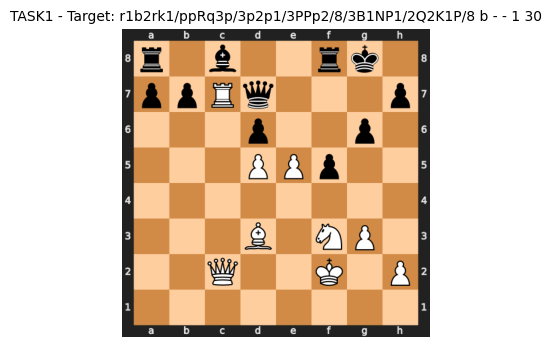

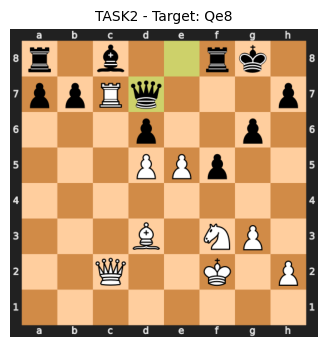

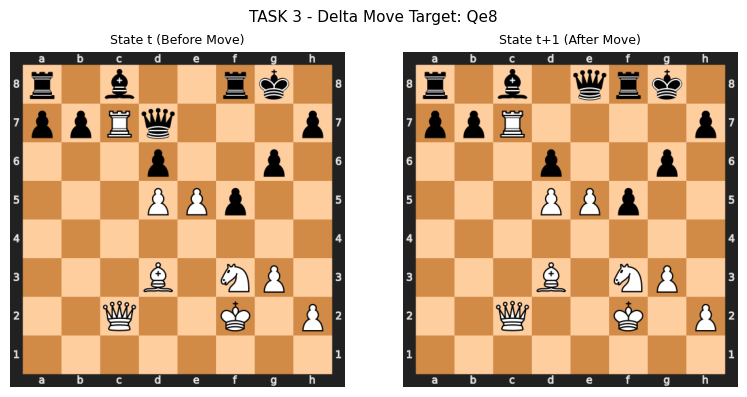

In [8]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# =====================================================================
# 1. Dataset Size and Directory Statistics
# =====================================================================

tasks = ["task1", "task2", "task3"]
splits = ["train", "validation", "test"]
stats = []

print("=== DATASET STATISTICS ===")
for task in tasks:
  for split in splits:
    split_dir = Path(f"dataset_{task}/{split}")
    if not split_dir.exists():
      stats.append({
          "Task": task,
          "Split": split,
          "Samples": 0,
          "Total Size (MB)": 0.0,
      })
      continue

    sample_folders = [f for f in split_dir.iterdir() if f.is_dir()]
    total_bytes = sum(
        f.stat().st_size for f in split_dir.rglob("*") if f.is_file()
    )
    total_mb = total_bytes / (1024 * 1024)

    stats.append({
        "Task": task,
        "Split": split,
        "Samples": len(sample_folders),
        "Total Size (MB)": round(total_mb, 2),
    })

stats_df = pd.DataFrame(stats)
display(stats_df)


# =====================================================================
# 2. Integrity and Metadata Verification Check
# =====================================================================

print("\n=== INTEGRITY & SCHEMA VERIFICATION ===")
for task in tasks:
  split_dir = Path(f"dataset_{task}/train")
  if not split_dir.exists():
    continue

  sample_folders = sorted([f for f in split_dir.iterdir() if f.is_dir()])
  if not sample_folders:
    print(f"[{task.upper()}] No samples found.")
    continue

  # Verify the first sample
  first_sample = sample_folders[0]
  meta_path = first_sample / "metadata.json"

  with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

  # Check that all referenced image files exist on disk
  missing_images = [
      f for f in meta["image_files"] if not (first_sample / f).exists()
  ]

  print(f"\nTask: {task.upper()} ({first_sample.name})")
  print(f"  - Puzzle ID:      {meta.get('puzzle_id')}")
  print(f"  - FEN:            {meta.get('fen')}")
  print(f"  - Target:         {meta.get('target')}")
  print(f"  - Expected Files: {meta.get('image_files')}")
  print(
      f"  - Status:         {'[OK]' if not missing_images else '[MISSING FILES: ' + str(missing_images) + ']'}"
  )


# =====================================================================
# 3. Visual Inspection for Task 1, Task 2, and Task 3
# =====================================================================

print("\n=== VISUAL SAMPLE INSPECTION ===")

for task in tasks:
  sample_dir = Path(f"dataset_{task}/train/sample_000000")
  if not sample_dir.exists():
    continue

  with open(sample_dir / "metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

  image_files = meta["image_files"]

  if task in ["task1", "task2"]:
    # Single image visualization
    img_path = sample_dir / image_files[0]
    img = Image.open(img_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{task.upper()} - Target: {meta['target']}", fontsize=10)
    plt.show()

  elif task == "task3":
    # Dual-image pair visualization (State t and State t+1 side-by-side)
    img_t_path = sample_dir / image_files[0]
    img_t1_path = sample_dir / image_files[1]

    img_t = Image.open(img_t_path)
    img_t1 = Image.open(img_t1_path)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_t)
    axes[0].set_title("State t (Before Move)", fontsize=9)
    axes[0].axis("off")

    axes[1].imshow(img_t1)
    axes[1].set_title("State t+1 (After Move)", fontsize=9)
    axes[1].axis("off")

    fig.suptitle(
        f"TASK 3 - Delta Move Target: {meta['target']}", fontsize=11, y=0.98
    )
    plt.tight_layout()
    plt.show()

Upload Datasets on hugging face using predefied functions on utilities.py

In [9]:
# 4. Upload each dataset to Hugging Face
ORGANIZATION_NAME = "bdatm-project"  # Sostituisci con il nome esatto dell'Org

print("\n==================== UPLOADING TO HUGGING FACE ====================")
for task in tasks:
    remote_dataset_name = f"dataset_{task}"

    upload_dataset_to_hub(
        local_dir=f"dataset_{task}",
        dataset_name=remote_dataset_name,
        namespace=ORGANIZATION_NAME,
        private=False,  # Imposta su True se vuoi che resti privato
        commit_message=f"Upload {remote_dataset_name} splits (train, validation, test)"
    )

print("\nAll datasets have been uploaded successfully to Hugging Face!")


==================== UPLOADING TO HUGGING FACE ====================

--- Hugging Face Authentication Required ---


Authenticated as: TommasoBergonzoni
Target namespace: bdatm-project

Target Dataset URL: https://huggingface.co/datasets/bdatm-project/dataset_task1
Uploading files from 'dataset_task1'...
Dataset 'bdatm-project/dataset_task1' successfully synchronized!
Authenticated as: TommasoBergonzoni
Target namespace: bdatm-project

Target Dataset URL: https://huggingface.co/datasets/bdatm-project/dataset_task2
Uploading files from 'dataset_task2'...
Dataset 'bdatm-project/dataset_task2' successfully synchronized!
Authenticated as: TommasoBergonzoni
Target namespace: bdatm-project

Target Dataset URL: https://huggingface.co/datasets/bdatm-project/dataset_task3
Uploading files from 'dataset_task3'...
Dataset 'bdatm-project/dataset_task3' successfully synchronized!

All datasets have been uploaded successfully to Hugging Face!
